In [1]:
import torch
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.matmul.allow_tf32 = False
from tqdm import tqdm
import numpy as np
from borzoi_pytorch import Borzoi
from borzoi_pytorch.config_borzoi import BorzoiConfig
from borzoi_pytorch.pytorch_borzoi_helpers import predict_tracks

/Users/jlinder/miniforge3/envs/torch_py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### We check if all tracks of the WT sequence of the EQTL example are predicted with the Pytorch model as with the original Calico TF keras model

In [2]:
device = 'cpu'
folds = 1
model_folds = []
for fold in tqdm(range(folds)):
    borzoi = Borzoi.from_pretrained(None, config=BorzoiConfig(), state_dict=torch.load('borzoi-replicate-0.pt'))
    borzoi.to(device)
    borzoi.eval()
    model_folds.append(borzoi)

  0%|                                                                                             | 0/1 [00:00<?, ?it/s]Some weights of Borzoi were not initialized from the model checkpoint at None and are newly initialized: ['final_joined_convs.0.norm.num_batches_tracked', 'horizontal_conv0.norm.num_batches_tracked', 'horizontal_conv1.norm.num_batches_tracked', 'res_tower.0.norm.num_batches_tracked', 'res_tower.2.norm.num_batches_tracked', 'res_tower.4.norm.num_batches_tracked', 'res_tower.6.norm.num_batches_tracked', 'res_tower.8.norm.num_batches_tracked', 'unet1.1.norm.num_batches_tracked', 'upsampling_unet0.0.norm.num_batches_tracked', 'upsampling_unet1.0.norm.num_batches_tracked']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.28it/s]


In [3]:
slices = [7531, 7532, 7533] # gtex blood tracks

In [4]:
sequence_one_hot_wt = torch.as_tensor(np.load('../wt_seq.npy')).to(device)
wt_pred_across_folds_pt = model_folds[0](sequence_one_hot_wt.permute(1,0)[None, ...])[:, slices, :].permute(0, 2,1).cpu().detach().numpy()

In [5]:
wt_pred_across_folds_pt.shape

(1, 6144, 3)

In [6]:
wt_pred_across_folds_pt

array([[[8.2024168e-03, 1.2812457e-03, 4.1999859e-03],
        [6.3262964e-03, 1.0860519e-03, 3.3887499e-03],
        [5.8659730e-03, 1.0399456e-03, 3.0810195e-03],
        ...,
        [5.6250620e-04, 7.6875585e-05, 2.7145477e-04],
        [5.8907550e-04, 8.6281107e-05, 3.0305283e-04],
        [5.1202485e-04, 7.4757365e-05, 2.4805623e-04]]], dtype=float32)

In [8]:
wt_pred_across_folds_tf = np.load('borzoi_wt_pred_across_folds.npy')

In [9]:
wt_pred_across_folds_pt.shape, wt_pred_across_folds_tf.shape

((1, 6144, 3), (1, 6144, 3))

In [10]:
np.allclose(wt_pred_across_folds_pt,wt_pred_across_folds_tf,rtol=0, atol = 0.00001)

True

#### Up to numerical precision, the Borzoi-ensemble ported to Pytorch gets the same results as the TF-Borzoi

In [11]:
wt_pred_across_folds_pt.min(), wt_pred_across_folds_tf.min()

(5.584785e-06, 5.5847745e-06)

In [12]:
wt_pred_across_folds_pt.max(), wt_pred_across_folds_tf.max()

(2.5435667, 2.5435662)

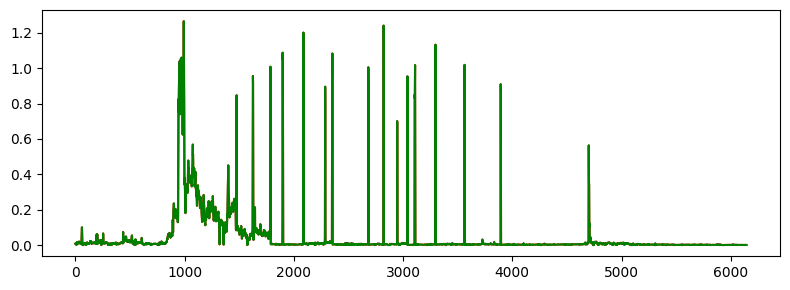

In [13]:
import matplotlib.pyplot as plt

f = plt.figure(figsize=(8, 3))

plt.plot(np.arange(wt_pred_across_folds_pt.shape[1]), wt_pred_across_folds_pt[0, :, 0], color='red')
plt.plot(np.arange(wt_pred_across_folds_tf.shape[1]), wt_pred_across_folds_tf[0, :, 0], color='green')

plt.tight_layout()

plt.show()
